# Bước 02 — Huấn luyện DDPM (dự đoán noise)

Notebook giải thích từng phần của [`02_train_ddpm.py`](./02_train_ddpm.py).

**Mục tiêu:** Hiểu *reverse process học được* — UNet không học vẽ ảnh trực tiếp, mà học **đoán noise** đã cộng vào `x_t` ở mỗi timestep `t`.

| Khái niệm | Ý nghĩa nhanh |
|-----------|----------------|
| `epsilon` (noise) | Nhiễu Gaussian thật dùng trong `q_sample` |
| `epsilon_pred` | Output UNet — cố gắng khớp `epsilon` |
| Loss | `MSE(epsilon_pred, epsilon)` |
| `t ~ Uniform(0, T-1)` | Mỗi batch, mỗi ảnh random một mức nhiễu |

**Chạy notebook:** kernel Python 3.10+ · `pip install -r requirements.txt` · chạy **tuần tự từ trên xuống**.

> **Thời gian:** mặc định `NUM_EPOCHS = 3` (~ vài phút trên GPU/MPS). Script gốc dùng 15 epoch (~45 phút MPS) để chất lượng giống README.

> Liên hệ SwiftEdit: UNet ở đây học denoise từng bước; SwiftEdit thay **chuỗi inversion** bằng mạng `F_theta` một bước — nhưng vẫn dựa trên ý tưởng “biết noise / latent ở timestep cố định”.

## 0. Setup — đường dẫn & import

Notebook phải chạy từ thư mục `learn/diffusion-from-scratch/` (cùng cấp với `diffusion/`).

In [1]:
%matplotlib inline

import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "diffusion" / "unet.py").exists():
    raise FileNotFoundError(
        f"Không thấy diffusion/unet.py trong {ROOT}.\n"
        "Mở notebook từ thư mục learn/diffusion-from-scratch/ hoặc cd vào đó trước."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from diffusion import LinearSchedule, UNet
from diffusion.utils import set_seed, get_device

set_seed(42)
device = get_device()
assets_dir = ROOT / "assets"
assets_dir.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("PyTorch:", torch.__version__)
print("Device:", device)

ROOT: /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch
PyTorch: 2.12.0
Device: mps


## 1. Mục tiêu huấn luyện — tại sao dự đoán noise?

Sau bước 01, ta biết forward process:

```
x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
```

**Huấn luyện DDPM** (Ho et al., 2020):

1. Lấy ảnh sạch `x_0` từ dataset
2. Chọn timestep ngẫu nhiên `t`
3. Tạo `x_t` bằng `q_sample` (biết `epsilon` vì ta tự sample)
4. UNet nhận `(x_t, t)` → dự đoán `epsilon_pred`
5. Minimize `||epsilon_pred - epsilon||²`

Khi sampling (bước 03), model dùng `epsilon_pred` để **lùi từng bước** `x_t → x_{t-1}` qua `schedule.p_sample`.

## 2. Dataset MNIST — scale về `[-1, 1]`

Giống script gốc: `ToTensor()` → `[0,1]`, rồi `x * 2 - 1` để khớp công thức diffusion paper.

Dataset: 60,000 ảnh train
Batch shape: (8, 1, 28, 28) — (batch, channel, H, W)
Min / max pixel: -1.0, 1.0


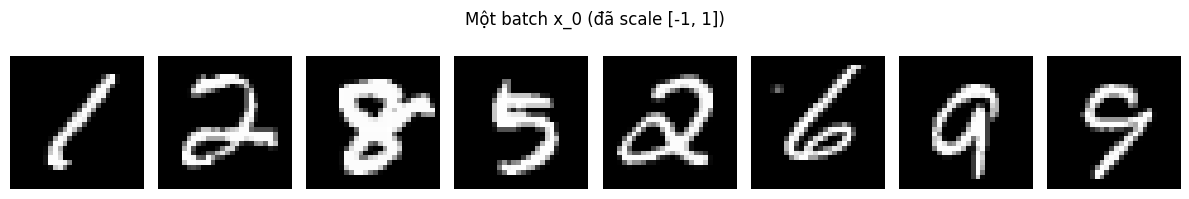

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),
])
dataset = datasets.MNIST(
    ROOT / "data", train=True, download=True, transform=transform
)

BATCH_SIZE = 128
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

x_0, label = next(iter(loader))
x_0 = x_0[:8]  # 8 ảnh demo
print(f"Dataset: {len(dataset):,} ảnh train")
print(f"Batch shape: {tuple(x_0.shape)} — (batch, channel, H, W)")
print(f"Min / max pixel: {x_0.min():.1f}, {x_0.max():.1f}")

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img in zip(axes, x_0):
    ax.imshow((img.squeeze() + 1) / 2, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Một batch x_0 (đã scale [-1, 1])", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Model & schedule

- **`LinearSchedule(T=1000)`** — cùng schedule bước 01, chuyển lên `device` để train nhanh hơn
- **`UNet(in_ch=1, base_ch=32, time_dim=128)`** — ~1.4M tham số; nhận `(x_t, t)` trả tensor cùng shape với noise

Time embedding: sinusoidal encoding của `t` được inject vào mỗi ResBlock (xem `diffusion/unet.py`).

In [3]:
T = 1000
LR = 2e-4

schedule = LinearSchedule(T=T, device=device)
model = UNet(in_ch=1, base_ch=32, time_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

num_params = sum(p.numel() for p in model.parameters())
print(f"Schedule T = {schedule.T}")
print(f"U-Net parameters: {num_params:,}")
print(f"Optimizer: Adam, lr = {LR}")

Schedule T = 1000
U-Net parameters: 1,422,721
Optimizer: Adam, lr = 0.0002


## 4. Một bước train — minh họa trên 1 batch

Cell dưới chạy **đúng logic** trong vòng lặp `02_train_ddpm.py`, nhưng in thêm thông tin để thấy:

- `t` khác nhau cho từng ảnh trong batch
- `x_t` = ảnh nhiễu tương ứng
- loss giảm sau vài bước gradient (overfit mini-batch — chỉ để demo)

### Demo thuần Python (không thư viện)

PyTorch **không** gọi `update(model)`. Optimizer nắm tham số từ đầu (`Adam(model.parameters())`), rồi `step()` **sửa weight tại chỗ**.

Ở đây `w` = 1 weight duy nhất (thay ~1.4M weight UNet).

| PyTorch | Demo | Ý nghĩa |
|---------|------|---------|
| `optimizer = Adam(model.parameters())` | `w = 0.0` | Khai báo tham số cần học |
| `optimizer.zero_grad()` | `grad_w = 0` | Xóa gradient cũ |
| `loss.backward()` | `grad_w = 2 * (noise_pred - noise_true) * x_t` | Tính ∂loss/∂w → `param.grad` |
| `optimizer.step()` | `w = w - lr * grad_w` | Sửa weight (SGD; Adam phức tạp hơn nhưng cùng ý) |

`step()` tương đương:

```python
# PyTorch làm in-place trên từng param — không cần model = update(model)
for param in model.parameters():
    param.data = param.data - lr * param.grad
```

In [ ]:
# Đã có sẵn từ forward process (trong train thật: q_sample tạo ra)
x_t = 1.2
noise_true = 0.5

# "Model" = 1 tham số w (thay cho hàng triệu tham số UNet)
w = 0.0
lr = 0.3

for step in range(50):
    noise_pred = w * x_t                    # forward: model(x_t, t)
    loss = (noise_pred - noise_true) ** 2   # loss: F.mse_loss(noise_pred, noise)

    grad_w = 0                              # optimizer.zero_grad()
    grad_w = 2 * (noise_pred - noise_true) * x_t  # loss.backward()
    w = w - lr * grad_w                     # optimizer.step()

    if step % 10 == 0 or step >= 46 or step <= 5:
        print(
            f"step {step}\n"
            f"  - noise_pred = {noise_pred:.4f}\n"
            f"  - loss = {loss:.6f}\n"
            f"  - grad_w = {grad_w:.6f}   ← backward\n"
            f"  - w = {w:.6f}             ← step"
        )

print(f"\nnoise thật: {noise_true}")
print(f"sau 50 bước: w*x_t = {w * x_t:.4f}  (gần noise thật)")
print(f"loss cuối: {loss:.6f}")

step 0
  - noise_pred = 0.0000
  - loss = 0.250000
  - grad_w = -1.200000   ← backward
  - w = 0.360000             ← step
step 1
  - noise_pred = 0.4320
  - loss = 0.004624
  - grad_w = -0.163200   ← backward
  - w = 0.408960             ← step
step 2
  - noise_pred = 0.4908
  - loss = 0.000086
  - grad_w = -0.022195   ← backward
  - w = 0.415619             ← step
step 3
  - noise_pred = 0.4987
  - loss = 0.000002
  - grad_w = -0.003019   ← backward
  - w = 0.416524             ← step
step 4
  - noise_pred = 0.4998
  - loss = 0.000000
  - grad_w = -0.000411   ← backward
  - w = 0.416647             ← step
step 5
  - noise_pred = 0.5000
  - loss = 0.000000
  - grad_w = -0.000056   ← backward
  - w = 0.416664             ← step
step 10
  - noise_pred = 0.5000
  - loss = 0.000000
  - grad_w = -0.000000   ← backward
  - w = 0.416667             ← step
step 20
  - noise_pred = 0.5000
  - loss = 0.000000
  - grad_w = 0.000000   ← backward
  - w = 0.416667             ← step
step 30
  - noi

### Demo OOP — `MyUNet` + `MyAdam` (PyTorch làm vậy bên trong)

Cell trên dùng biến `w` lẻ. PyTorch thật tổ chức thành:

- **Model** giữ `parameters()` + `forward(x_t, t)` — UNet **bắt buộc biết timestep `t`**
- **Optimizer** giữ **reference** tới cùng list đó lúc `Adam(model.parameters())`
- `step()` sửa `param.data` **in-place** — không có `model = update(model)`

Cell dưới viết lại bằng class thuần Python. `forward(x_t, t)` dùng `t` qua hệ số `1 - t/T` (đơn giản hóa time embedding).

In [21]:
class Param:
    """Giống 1 tensor weight trong PyTorch: có .data và .grad"""

    def __init__(self, data):
        self.data = data
        self.grad = 0.0


class MyUNet:
    """UNet giả lập — 1 weight w; nhận (x_t, t) như UNet thật."""

    def __init__(self, T=1000):
        self.T = T
        self.w = Param(0.0)

    def parameters(self):
        return [self.w]

    def time_scale(self, t):
        """Demo đơn giản: t lớn → nhiễu nhiều → scale khác (UNet thật: sinusoidal embedding)."""
        return 1.0 - t / self.T

    def forward(self, x_t, t):
        # Giống gọi: model(x_t, t) trong PyTorch
        return self.w.data * x_t * self.time_scale(t)


class MyAdam:
    def __init__(self, params, lr=0.3):
        self.params = params
        self.lr = lr

    def zero_grad(self):
        for p in self.params:
            p.grad = 0.0

    def step(self):
        for p in self.params:
            p.data = p.data - self.lr * p.grad


def backward_demo(noise_pred, noise_true, x_t, t, param, T=1000):
    """Tương đương loss.backward() — grad qua cả x_t và time_scale(t)."""
    scale = 1.0 - t / T
    param.grad = 2 * (noise_pred - noise_true) * x_t * scale


# --- Train: cố định (x_t, t, noise) như cell overfit 4 ảnh ---
T = 1000
x_t = 1.2
t = 400                    # timestep cố định cho demo
noise_true = 0.5

model = MyUNet(T=T)
optimizer = MyAdam(model.parameters(), lr=0.3)
scale = model.time_scale(t)

print(f"x_t={x_t}, t={t}, time_scale(t)={scale:.3f}")
print("Optimizer nắm đúng weight của model?", optimizer.params[0] is model.w)
print(f"w ban đầu: {model.w.data}")

for step in range(50):
    noise_pred = model.forward(x_t, t)              # forward(x_t, t)
    loss = (noise_pred - noise_true) ** 2

    optimizer.zero_grad()
    backward_demo(noise_pred, noise_true, x_t, t, model.w, T=T)
    optimizer.step()

print(f"\nw sau train: {model.w.data:.4f}")
print(f"noise_pred = {model.forward(x_t, t):.4f}  (target {noise_true})")
print(f"loss cuối: {loss:.6f}")
print("\n→ model(x_t, t): cùng x_t nhưng đổi t → output đổi (thử t=900 bên dưới)")
print(f"   forward(x_t, t=400) = {model.forward(x_t, 400):.4f}")
print(f"   forward(x_t, t=900) = {model.forward(x_t, 900):.4f}")

x_t=1.2, t=400, time_scale(t)=0.600
Optimizer nắm đúng weight của model? True
w ban đầu: 0.0

w sau train: 0.6944
noise_pred = 0.5000  (target 0.5)
loss cuối: 0.000000

→ model(x_t, t): cùng x_t nhưng đổi t → output đổi (thử t=900 bên dưới)
   forward(x_t, t=400) = 0.5000
   forward(x_t, t=900) = 0.0833


Noise shape: torch.Size([4, 1, 28, 28])
Timesteps t cho 4 ảnh: [280, 493, 820, 921]
alpha_bar[t]: ['0.443', '0.083', '0.001', '0.000']
Loss trước train (random init): 0.0191
Loss sau 50 step (cùng batch): 0.0008


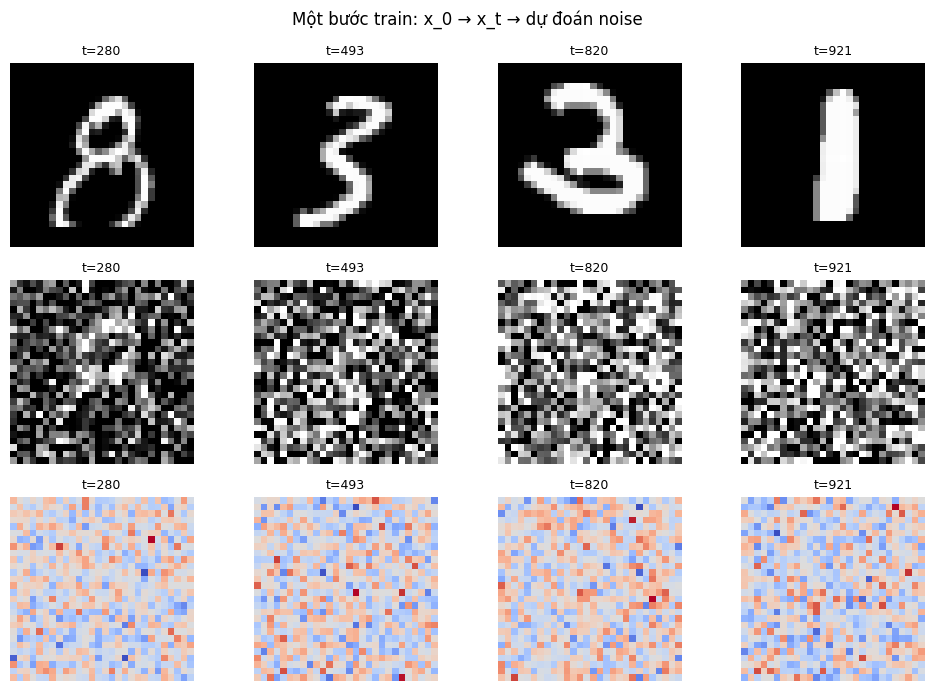

In [8]:
demo_batch, _ = next(iter(loader))
demo_batch = demo_batch[:4].to(device)

t = torch.randint(0, T, (demo_batch.shape[0],), device=device)
noise = torch.randn_like(demo_batch)
x_t, noise = schedule.q_sample(demo_batch, t, noise)

print(f"Noise shape: {noise.shape}")
print("Timesteps t cho 4 ảnh:", t.tolist())
print("alpha_bar[t]:", [f"{schedule.alpha_bar[ti]:.3f}" for ti in t.tolist()])

with torch.no_grad():
    noise_pred_before = model(x_t, t)
    loss_before = F.mse_loss(noise_pred_before, noise).item()
print(f"Loss trước train (random init): {loss_before:.4f}")

# Overfit 4 ảnh — chỉ minh họa gradient hoạt động
model.train()
for step in range(50):
    noise_pred = model(x_t, t)
    loss = F.mse_loss(noise_pred, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    noise_pred_after = model(x_t, t)
    loss_after = F.mse_loss(noise_pred_after, noise).item()
print(f"Loss sau 50 step (cùng batch): {loss_after:.4f}")

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
rows = [(demo_batch, "x_0"), (x_t, "x_t (noised)"), (noise_pred_after, "epsilon_pred")]
for row_idx, (tensor, row_title) in enumerate(rows):
    for col in range(4):
        img = tensor[col, 0].cpu().numpy()
        if row_idx < 2:
            img = (img + 1) / 2
        else:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[row_idx, col].imshow(img, cmap="gray" if row_idx < 2 else "coolwarm", vmin=0, vmax=1)
        if col == 0:
            axes[row_idx, col].set_ylabel(row_title)
        axes[row_idx, col].set_title(f"t={t[col].item()}", fontsize=9)
        axes[row_idx, col].axis("off")
plt.suptitle("Một bước train: x_0 → x_t → dự đoán noise", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Huấn luyện đầy đủ — vòng lặp epoch

Logic giống hệt [`02_train_ddpm.py`](./02_train_ddpm.py).

Đặt `SKIP_TRAIN_IF_EXISTS = True` để bỏ qua nếu đã có `assets/ddpm_mnist.pt` (tiết kiệm thời gian khi chỉ xem lại notebook).

In [5]:
# --- Hyperparameters (script gốc: 15 epoch) ---
NUM_EPOCHS = 3
SKIP_TRAIN_IF_EXISTS = True
CHECKPOINT = assets_dir / "ddpm_mnist.pt"

# Reset model nếu train từ đầu
if not (SKIP_TRAIN_IF_EXISTS and CHECKPOINT.exists()):
    model = UNet(in_ch=1, base_ch=32, time_dim=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0
        start = time.time()

        for x_0, _ in loader:
            x_0 = x_0.to(device)
            t = torch.randint(0, T, (x_0.shape[0],), device=device)
            noise = torch.randn_like(x_0)
            x_t, _ = schedule.q_sample(x_0, t, noise)

            noise_pred = model(x_t, t)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        elapsed = time.time() - start
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}  Loss: {avg_loss:.4f}  ({elapsed:.1f}s)")

    torch.save(model.state_dict(), CHECKPOINT)
    print(f"Đã lưu model → {CHECKPOINT}")
else:
    print(f"Bỏ qua train — đã có checkpoint: {CHECKPOINT}")
    model.load_state_dict(torch.load(CHECKPOINT, map_location=device, weights_only=True))
    losses = []  # không có curve mới; cell sau vẽ file PNG có sẵn nếu cần

Epoch 1/3  Loss: 0.0714  (91.0s)
Epoch 2/3  Loss: 0.0359  (98.9s)
Epoch 3/3  Loss: 0.0310  (125.4s)
Đã lưu model → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/ddpm_mnist.pt


## 6. Đường cong loss & lưu hình

Script gốc lưu `assets/training_loss.png`. Notebook hiển thị inline và (nếu vừa train) lưu thêm bản `_notebook`.

Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/training_loss_notebook.png


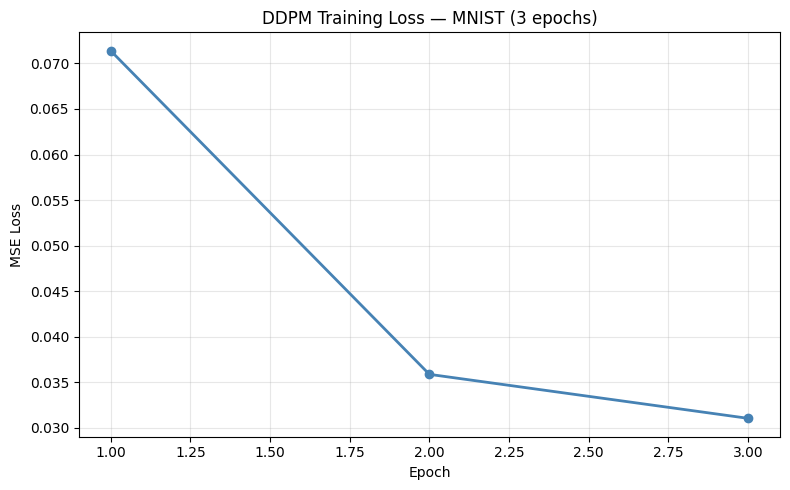

In [6]:
if losses:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, len(losses) + 1), losses, "o-", color="steelblue", linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"DDPM Training Loss — MNIST ({NUM_EPOCHS} epochs)")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    out_path = assets_dir / "training_loss_notebook.png"
    fig.savefig(out_path, dpi=150)
    print(f"Đã lưu → {out_path}")
    plt.show()
else:
    ref = assets_dir / "training_loss.png"
    if ref.exists():
        img = plt.imread(ref)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Training loss (từ lần train script trước)")
        plt.show()
    else:
        print("Chưa có loss curve — chạy train hoặc python 02_train_ddpm.py trước.")

## 7. Kiểm tra nhanh — noise thật vs dự đoán

Sau train, UNet nên dự đoán noise **gần** noise đã dùng trong `q_sample` (không hoàn hảo vì `t` random và model chưa converge nếu ít epoch).

t = 400, alpha_bar = 0.194
MSE(noise_pred, noise_true) = 0.0141


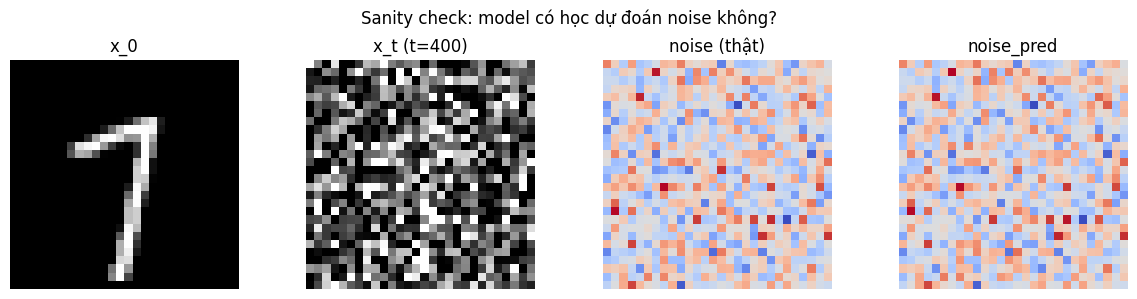

In [7]:
model.eval()
x_0_single = dataset[42][0].unsqueeze(0).to(device)
t_fixed = torch.tensor([400], device=device)
noise_true = torch.randn_like(x_0_single)
x_t, _ = schedule.q_sample(x_0_single, t_fixed, noise_true)

with torch.no_grad():
    noise_pred = model(x_t, t_fixed)
    mse = F.mse_loss(noise_pred, noise_true).item()

print(f"t = {t_fixed.item()}, alpha_bar = {schedule.alpha_bar[t_fixed].item():.3f}")
print(f"MSE(noise_pred, noise_true) = {mse:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
panels = [
    (x_0_single, "x_0", "gray", True),
    (x_t, f"x_t (t={t_fixed.item()})", "gray", True),
    (noise_true, "noise (thật)", "coolwarm", False),
    (noise_pred, "noise_pred", "coolwarm", False),
]
for ax, (tensor, title, cmap, scaled) in zip(axes, panels):
    img = tensor.squeeze().cpu().numpy()
    if scaled:
        img = (img + 1) / 2
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    else:
        ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Sanity check: model có học dự đoán noise không?", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Tóm tắt & bước tiếp theo

### Bạn vừa học được

1. **Objective DDPM:** predict noise, không predict `x_0` trực tiếp.
2. **Training loop:** random `t` mỗi batch → `q_sample` → MSE với UNet output.
3. **Time conditioning:** cùng UNet phải biết “đang ở bước nhiễu nào” qua embedding `t`.

### Bước tiếp theo trong repo

| File | Nội dung |
|------|----------|
| `03_sample_ddpm.py` | Sinh ảnh: nhiễu thuần → 1000 bước `p_sample` |
| `04_sample_ddim.py` | Cùng weights, chỉ ~50 bước (DDIM) |

### SwiftEdit (CS2309)

- Pipeline SD dùng UNet lớn hơn nhiều, nhưng **cùng ý**: latent/noise ở timestep cố định.
- Method cũ: nhiều bước inversion để tìm noise từ ảnh gốc.
- **SwiftEdit:** `F_theta(image, prompt)` → inverted noise **1 pass**, rồi edit pipeline chạy nhanh.

**Checklist hiểu bài (tự kiểm):**

- [ ] Giải thích được tại sao loss là MSE trên noise
- [ ] Biết vai trò random `t` khi train
- [ ] Phân biệt train (predict ε) vs sample (dùng ε để denoise)

→ Tiếp: [`03_sample_ddpm.py`](./03_sample_ddpm.py) hoặc quay lại [`tasks/theory_tasks.md`](../../tasks/theory_tasks.md).